# Loading Dataset

In [3]:
from keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
num_words=10000)

17464789/17464789 [==============================] - 35s 2us/step


In [51]:
test_data[1]

[1,
 14,
 22,
 3443,
 6,
 176,
 7,
 5063,
 88,
 12,
 2679,
 23,
 1310,
 5,
 109,
 943,
 4,
 114,
 9,
 55,
 606,
 5,
 111,
 7,
 4,
 139,
 193,
 273,
 23,
 4,
 172,
 270,
 11,
 7216,
 2,
 4,
 8463,
 2801,
 109,
 1603,
 21,
 4,
 22,
 3861,
 8,
 6,
 1193,
 1330,
 10,
 10,
 4,
 105,
 987,
 35,
 841,
 2,
 19,
 861,
 1074,
 5,
 1987,
 2,
 45,
 55,
 221,
 15,
 670,
 5304,
 526,
 14,
 1069,
 4,
 405,
 5,
 2438,
 7,
 27,
 85,
 108,
 131,
 4,
 5045,
 5304,
 3884,
 405,
 9,
 3523,
 133,
 5,
 50,
 13,
 104,
 51,
 66,
 166,
 14,
 22,
 157,
 9,
 4,
 530,
 239,
 34,
 8463,
 2801,
 45,
 407,
 31,
 7,
 41,
 3778,
 105,
 21,
 59,
 299,
 12,
 38,
 950,
 5,
 4521,
 15,
 45,
 629,
 488,
 2733,
 127,
 6,
 52,
 292,
 17,
 4,
 6936,
 185,
 132,
 1988,
 5304,
 1799,
 488,
 2693,
 47,
 6,
 392,
 173,
 4,
 2,
 4378,
 270,
 2352,
 4,
 1500,
 7,
 4,
 65,
 55,
 73,
 11,
 346,
 14,
 20,
 9,
 6,
 976,
 2078,
 7,
 5293,
 861,
 2,
 5,
 4182,
 30,
 3127,
 2,
 56,
 4,
 841,
 5,
 990,
 692,
 8,
 4,
 1669,
 398,
 229,
 10,


In [52]:
test_labels[1]

1

# Encoding the integer sequences into a binary matrix

In [11]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [53]:
x_test[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [14]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [15]:
y_train

array([1., 0., 0., ..., 0., 1., 0.], dtype=float32)

In [16]:
y_test

array([0., 1., 1., ..., 0., 0., 0.], dtype=float32)

# The model definition

In [19]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

2025-03-20 16:21:01.060747: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-03-20 16:21:01.061049: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-03-20 16:21:01.061478: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-03-20 16:21:01.061894: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-20 16:21:01.062380: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# Compiling the model

In [21]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])

# Configuring the optimizer

In [24]:
from keras import optimizers

model.compile(optimizer=optimizers.legacy.RMSprop(learning_rate=0.001),
loss='binary_crossentropy',
metrics=['accuracy'])

# Using custom losses and metrics

In [26]:
from keras import losses
from keras import metrics

model.compile(optimizer=optimizers.legacy.RMSprop(learning_rate=0.001),
loss=losses.binary_crossentropy,
metrics=[metrics.binary_accuracy])

# Setting aside a validation set

In [27]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# Training your model

In [55]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(partial_x_train, partial_y_train, epochs=30, batch_size=256, validation_data=(x_val, y_val))

Epoch 1/30


2025-03-21 15:11:13.010875: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


59/59 [==============================] - ETA: 0s - loss: 0.0079 - accuracy: 0.9982

2025-03-21 15:11:15.717417: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


59/59 [==============================] - 4s 42ms/step - loss: 0.0079 - accuracy: 0.9982 - val_loss: 0.7376 - val_accuracy: 0.8787
Epoch 2/30
59/59 [==============================] - 1s 19ms/step - loss: 0.0030 - accuracy: 0.9996 - val_loss: 0.7941 - val_accuracy: 0.8787
Epoch 3/30
59/59 [==============================] - 1s 16ms/step - loss: 0.0028 - accuracy: 0.9997 - val_loss: 0.8496 - val_accuracy: 0.8787
Epoch 4/30
59/59 [==============================] - 1s 16ms/step - loss: 0.0019 - accuracy: 0.9998 - val_loss: 0.9266 - val_accuracy: 0.8749
Epoch 5/30
59/59 [==============================] - 1s 15ms/step - loss: 0.0021 - accuracy: 0.9995 - val_loss: 0.9748 - val_accuracy: 0.8726
Epoch 6/30
59/59 [==============================] - 1s 15ms/step - loss: 9.8797e-04 - accuracy: 0.9999 - val_loss: 1.0431 - val_accuracy: 0.8720
Epoch 7/30
59/59 [==============================] - 1s 15ms/step - loss: 9.2465e-04 - accuracy: 0.9998 - val_loss: 1.1135 - val_accuracy: 0.8708
Epoch 8/30
59/59

# Plotting the training and validation loss

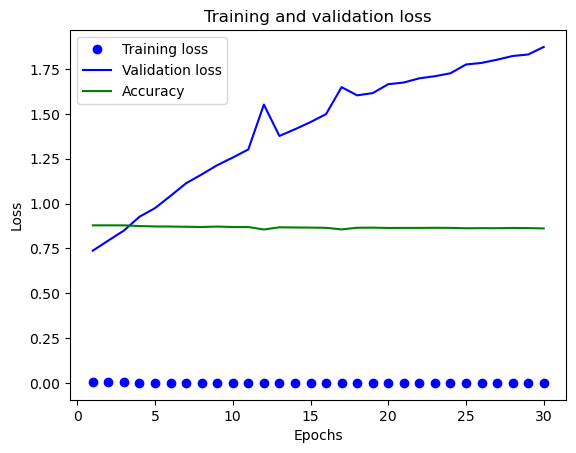

In [56]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_values = history_dict['val_accuracy']

epochs = range(1, len(accuracy_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.plot(epochs, accuracy_values, 'g', label='Accuracy')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Plotting the training and validation accuracy

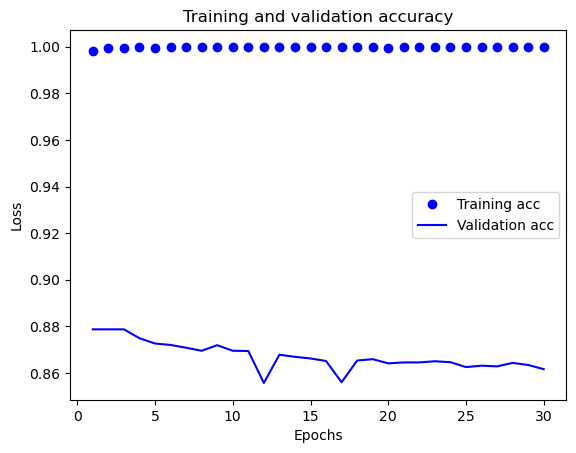

In [57]:
plt.clf()
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Retraining a model from scratch

In [58]:
model = models.Sequential()

model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
loss='binary_crossentropy',
metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4


2025-03-21 15:15:15.404059: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


49/49 [==============================] - 1s 16ms/step - loss: 0.4995 - accuracy: 0.8043
Epoch 2/4
49/49 [==============================] - 1s 13ms/step - loss: 0.2807 - accuracy: 0.9029
Epoch 3/4
49/49 [==============================] - 1s 13ms/step - loss: 0.2098 - accuracy: 0.9254
Epoch 4/4
 10/782 [..............................] - ETA: 4s - loss: 0.2383 - accuracy: 0.9000  

2025-03-21 15:15:21.235191: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


782/782 [==============================] - 8s 9ms/step - loss: 0.2917 - accuracy: 0.8844


In [59]:
results

[0.2917466461658478, 0.884440004825592]

# Using a trained network to generate predictions on new data

In [60]:
model.predict(x_test)

 59/782 [=>............................] - ETA: 1s

2025-03-21 15:16:49.087445: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


782/782 [==============================] - 2s 2ms/step


array([[0.20477076],
       [0.9999894 ],
       [0.967508  ],
       ...,
       [0.13072555],
       [0.11984857],
       [0.70227385]], dtype=float32)